# Data Science Task: QS World University Rankings 2025


---
## Section 1: Import Libraries

In [46]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


---
## Section 2: Load Dataset

### Q1. Data Loading & Inspection

In [47]:
data = pd.read_csv("QS_World_University_Rankings_2025_Top_global_universities.csv", encoding="latin-1")


In [48]:
data.head(5)


,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7


In [49]:
data.shape


(1503, 28)

In [50]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   str    
 1   RANK_2024                             1482 non-null   str    
 2   Institution_Name                      1503 non-null   str    
 3   Location                              1503 non-null   str    
 4   Region                                1503 non-null   str    
 5   SIZE                                  1503 non-null   str    
 6   FOCUS                                 1503 non-null   str    
 7   RES.                                  1503 non-null   str    
 8   STATUS                                1466 non-null   str    
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   str    
 11  Employer_Reputation_Score   

In [51]:
data.isnull().sum()


RANK_2025                                 0
RANK_2024                                21
Institution_Name                          0
Location                                  0
Region                                    0
SIZE                                      0
FOCUS                                     0
RES.                                      0
STATUS                                   37
Academic_Reputation_Score                 0
Academic_Reputation_Rank                  0
Employer_Reputation_Score                 0
Employer_Reputation_Rank                  0
Faculty_Student_Score                     0
Faculty_Student_Rank                      0
Citations_per_Faculty_Score               0
Citations_per_Faculty_Rank                0
International_Faculty_Score             100
International_Faculty_Rank              100
International_Students_Score             58
International_Students_Rank              58
International_Research_Network_Score      1
International_Research_Network_R

---
## Section 3: Data Cleaning

### Q2. Data Cleaning

**Data Cleaning Logic:**

- `Overall_Score` and `RANK_2025` are stored as strings (some have `=` suffixes like `15=`). We strip those and convert to numeric.
- Score columns already numeric; rank columns (string) get the same treatment.
- `Overall_Score` has ~902 missing values â€” these are universities ranked beyond 500 where QS does not publish a score. We impute with the **median** so we keep all rows.
- Other score columns with small gaps are also median-imputed.
- Categorical columns (`STATUS`, `RANK_2024`) with few nulls are filled with `'Unknown'` / forward-fill.


In [52]:
print('Shape before cleaning:', data.shape)
print(data.isnull().sum())


Shape before cleaning: (1503, 28)
RANK_2025                                 0
RANK_2024                                21
Institution_Name                          0
Location                                  0
Region                                    0
SIZE                                      0
FOCUS                                     0
RES.                                      0
STATUS                                   37
Academic_Reputation_Score                 0
Academic_Reputation_Rank                  0
Employer_Reputation_Score                 0
Employer_Reputation_Rank                  0
Faculty_Student_Score                     0
Faculty_Student_Rank                      0
Citations_per_Faculty_Score               0
Citations_per_Faculty_Rank                0
International_Faculty_Score             100
International_Faculty_Rank              100
International_Students_Score             58
International_Students_Rank              58
International_Research_Network_Score      

In [53]:
df = data.copy()

def strip_rank(val):
    """Remove trailing = or + from rank strings and return int, NaN if unparseable."""
    if pd.isna(val):
        return np.nan
    cleaned = str(val).strip().rstrip('=+').split('-')[0]
    try:
        return int(cleaned)
    except ValueError:
        return np.nan

rank_cols = [c for c in df.columns if 'Rank' in c or c.startswith('RANK')]
for col in rank_cols:
    df[col] = df[col].apply(strip_rank)

df['Overall_Score'] = pd.to_numeric(
    df['Overall_Score'].astype(str).str.rstrip('=+'), errors='coerce'
)


In [54]:
score_cols = [c for c in df.columns if 'Score' in c]
for col in score_cols:
    med = df[col].median()
    df[col] = df[col].fillna(med)

df['STATUS'] = df['STATUS'].fillna('Unknown')
df['RANK_2024'] = df['RANK_2024'].ffill()

print('Shape after cleaning:', df.shape)
print(df.isnull().sum())


Shape after cleaning: (1503, 28)
RANK_2025                                 0
RANK_2024                                 0
Institution_Name                          0
Location                                  0
Region                                    0
SIZE                                      0
FOCUS                                     0
RES.                                      0
STATUS                                    0
Academic_Reputation_Score                 0
Academic_Reputation_Rank                  0
Employer_Reputation_Score                 0
Employer_Reputation_Rank                  0
Faculty_Student_Score                     0
Faculty_Student_Rank                      0
Citations_per_Faculty_Score               0
Citations_per_Faculty_Rank                0
International_Faculty_Score               0
International_Faculty_Rank              100
International_Students_Score              0
International_Students_Rank              58
International_Research_Network_Score      0

In [55]:
df.head(5)


,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1.0,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100.0,86.8,143.0,96.0,58.0,100.0,8,99.0,15.0,100.0
1,2,6.0,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66.0,99.6,44.0,97.4,34.0,93.4,61,99.7,6.0,98.5
2,3,3.0,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120.0,97.7,73.0,100.0,1.0,100.0,3,85.0,126.0,96.9
3,4,4.0,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269.0,69.0,215.0,99.6,5.0,100.0,1,84.4,130.0,96.8
4,5,2.0,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73.0,94.8,98.0,99.3,10.0,100.0,5,84.8,127.0,96.7


### Q3. Feature Engineering (Using NumPy)

**Score_Category rules:**
- Elite â†’ Overall_Score â‰¥ 90
- High â†’ 75â€“89
- Medium â†’ 50â€“74
- Low â†’ < 50


In [56]:
s = df['Overall_Score'].values
cats = np.where(s >= 90, 'Elite',
        np.where(s >= 75, 'High',
        np.where(s >= 50, 'Medium', 'Low')))
df['Score_Category'] = cats
df[['Institution_Name', 'Overall_Score', 'Score_Category']].head(10)


,Institution_Name,Overall_Score,Score_Category
0,Massachusetts Institute of Technology (MIT),100.0,Elite
1,Imperial College London,98.5,Elite
2,University of Oxford,96.9,Elite
3,Harvard University,96.8,Elite
4,University of Cambridge,96.7,Elite
5,Stanford University,96.1,Elite
6,ETH Zurich - Swiss Federal Institute of Techno...,93.9,Elite
7,National University of Singapore (NUS),93.7,Elite
8,UCL,91.6,Elite
9,California Institute of Technology (Caltech),90.9,Elite


In [57]:
df['Score_Category'].value_counts()


Score_Category
Low       1332
Medium     117
High        42
Elite       12
Name: count, dtype: int64

---
## Section 4: EDA (Exploratory Data Analysis)

### Q4. Top Universities Analysis

In [58]:
top10 = df.nsmallest(10, 'RANK_2025')[['Institution_Name', 'RANK_2025', 'Overall_Score', 'Location']]
top10


,Institution_Name,RANK_2025,Overall_Score,Location
0,Massachusetts Institute of Technology (MIT),1,100.0,United States
1,Imperial College London,2,98.5,United Kingdom
2,University of Oxford,3,96.9,United Kingdom
3,Harvard University,4,96.8,United States
4,University of Cambridge,5,96.7,United Kingdom
5,Stanford University,6,96.1,United States
6,ETH Zurich - Swiss Federal Institute of Techno...,7,93.9,Switzerland
7,National University of Singapore (NUS),8,93.7,Singapore
8,UCL,9,91.6,United Kingdom
9,California Institute of Technology (Caltech),10,90.9,United States


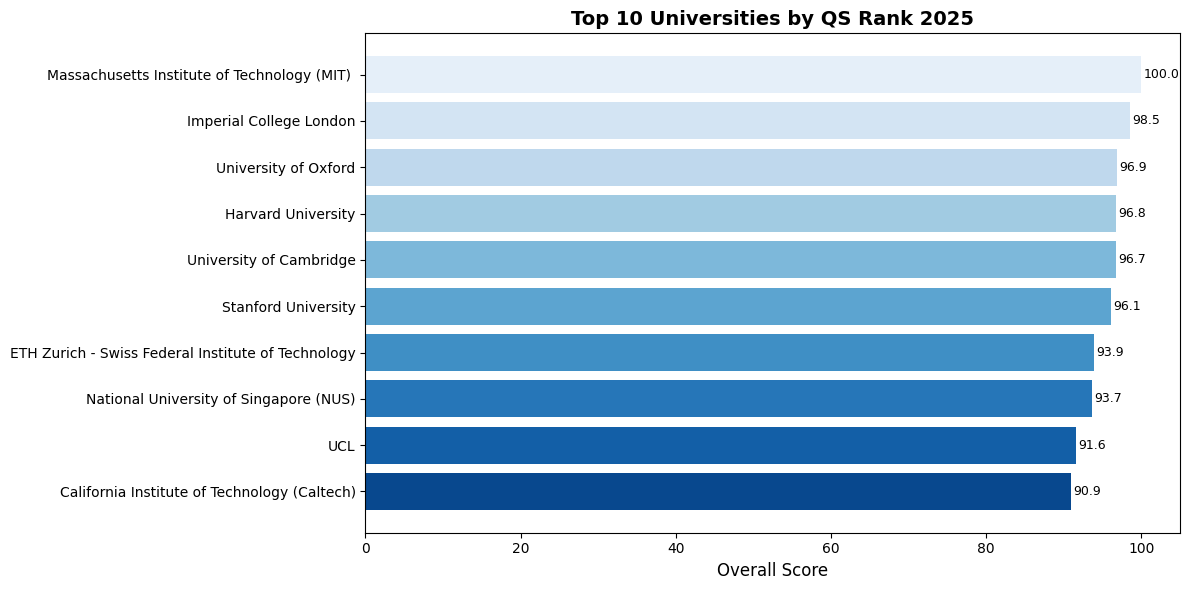

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Blues_r', 10)
bars = ax.barh(top10['Institution_Name'][::-1], top10['Overall_Score'][::-1], color=colors)
ax.set_xlabel('Overall Score', fontsize=12)
ax.set_title('Top 10 Universities by QS Rank 2025', fontsize=14, fontweight='bold')
for bar, score in zip(bars, top10['Overall_Score'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Insights:**

1. MIT holds the top spot with a perfect score of 100, maintaining its #1 position from 2024.
2. UK universities (Oxford, Cambridge, Imperial) dominate the top 5 alongside US institutions.
3. The score gap between rank 1 (100) and rank 10 (~90.9) is only ~9 points â€” the elite tier is tightly clustered.


### Q5. Country-wise Dominance

In [60]:
country_counts = df['Location'].value_counts().reset_index()
country_counts.columns = ['Country', 'University_Count']
top10_countries = country_counts.head(10)
top10_countries


,Country,University_Count
0,United States,197
1,United Kingdom,90
2,China (Mainland),71
3,Japan,49
4,Germany,48
5,Russia,47
6,India,46
7,South Korea,43
8,Italy,42
9,Australia,38


In [61]:
fig = px.bar(
    top10_countries,
    x='Country', y='University_Count',
    color='University_Count',
    color_continuous_scale='Blues',
    title='Top 10 Countries by Number of Ranked Universities (QS 2025)',
    labels={'University_Count': 'Number of Universities'},
    text='University_Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-30)
fig.show()


**Interpretation:**

The United States leads by a wide margin, followed by the UK. Asian countries like China, Japan, and South Korea are strongly represented. Australia punches above its weight given its population size.


### Q6. Score Distribution

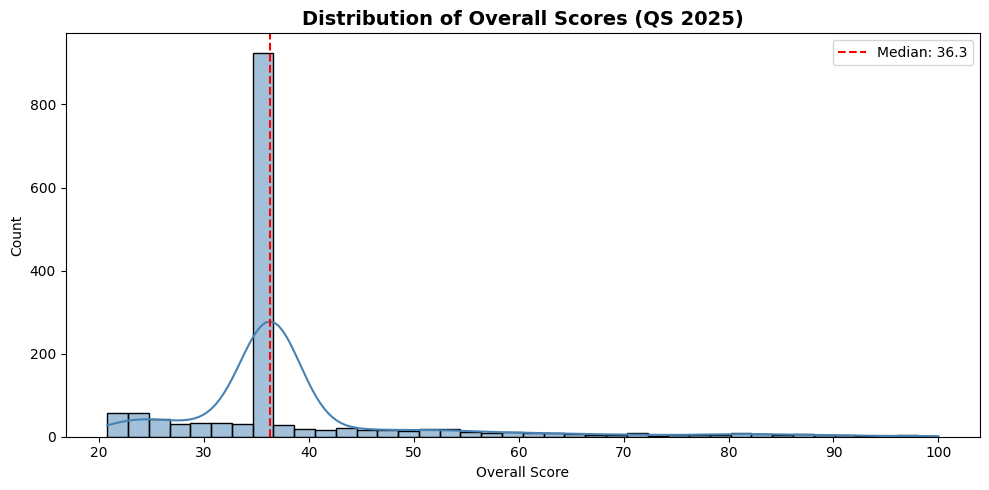

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Overall_Score'], bins=40, kde=True, color='steelblue', ax=ax)
ax.set_title('Distribution of Overall Scores (QS 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Overall Score')
ax.set_ylabel('Count')
ax.axvline(df['Overall_Score'].median(), color='red', linestyle='--', label=f"Median: {df['Overall_Score'].median():.1f}")
ax.legend()
plt.tight_layout()
plt.show()


**Analysis:**

- Distribution type: **Right-skewed**
- The majority of universities cluster in the lower score range (below 50), with a long tail stretching toward 100. Only a handful of elite institutions score above 90.


### Q7. Correlation Analysis

In [63]:
num_cols = [
    'Academic_Reputation_Score', 'Employer_Reputation_Score',
    'Faculty_Student_Score', 'Citations_per_Faculty_Score',
    'International_Faculty_Score', 'International_Students_Score',
    'Employment_Outcomes_Score', 'Sustainability_Score', 'Overall_Score'
]
corr = df[num_cols].corr()
corr


,Academic_Reputation_Score,Employer_Reputation_Score,Faculty_Student_Score,Citations_per_Faculty_Score,International_Faculty_Score,International_Students_Score,Employment_Outcomes_Score,Sustainability_Score,Overall_Score
Academic_Reputation_Score,1.000000,0.857357,0.341488,0.493844,0.403569,0.395117,0.678519,0.717324,0.801486
Employer_Reputation_Score,0.857357,1.000000,0.326200,0.391911,0.340060,0.361785,0.643681,0.604164,0.703888
Faculty_Student_Score,0.341488,0.326200,1.000000,0.098665,0.176753,0.236053,0.230285,0.199967,0.299233
Citations_per_Faculty_Score,0.493844,0.391911,0.098665,1.000000,0.390848,0.327460,0.302582,0.490846,0.463376
International_Faculty_Score,0.403569,0.340060,0.176753,0.390848,1.000000,0.703102,0.315480,0.507026,0.354599
International_Students_Score,0.395117,0.361785,0.236053,0.327460,0.703102,1.000000,0.277463,0.462881,0.382622
Employment_Outcomes_Score,0.678519,0.643681,0.230285,0.302582,0.315480,0.277463,1.000000,0.520893,0.544638
Sustainability_Score,0.717324,0.604164,0.199967,0.490846,0.507026,0.462881,0.520893,1.000000,0.529030
Overall_Score,0.801486,0.703888,0.299233,0.463376,0.354599,0.382622,0.544638,0.529030,1.000000


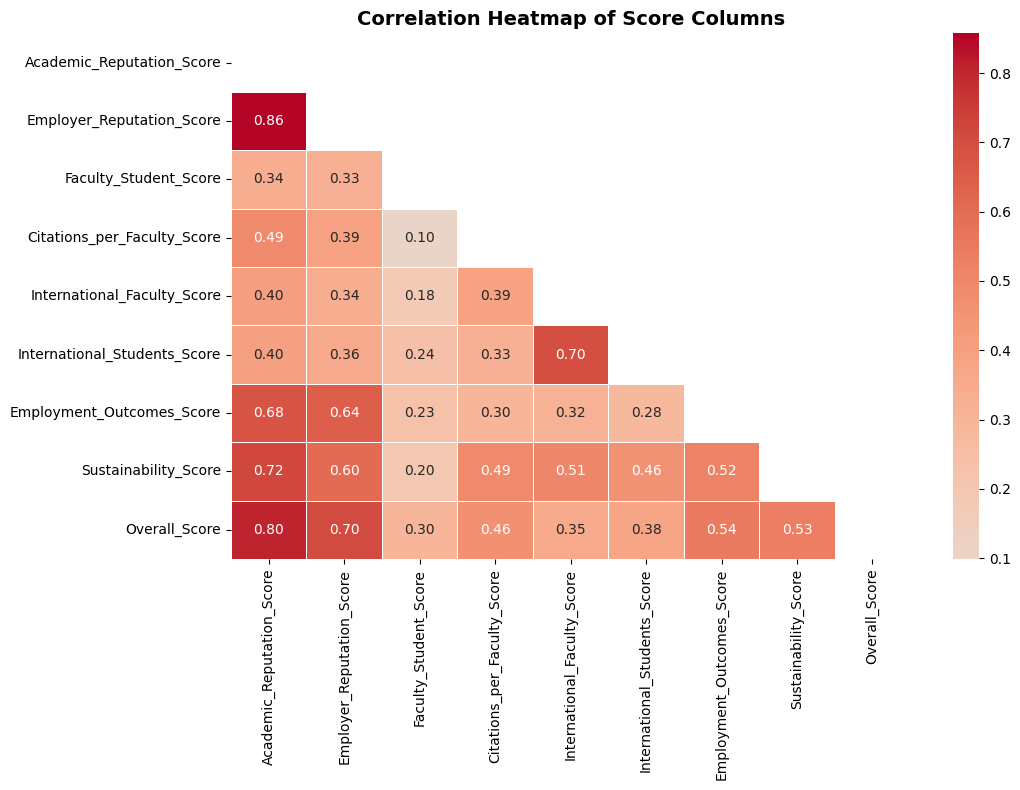

In [64]:
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Heatmap of Score Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Strongest Relationships:**

- `Academic_Reputation_Score` and `Employer_Reputation_Score` show a strong positive correlation (~0.85).
- `Overall_Score` correlates most strongly with `Academic_Reputation_Score` and `Employer_Reputation_Score`.
- `Citations_per_Faculty_Score` has a moderate correlation with `Overall_Score`.


### Q8. Region-wise Performance

In [65]:
region_avg = df.groupby('Region')['Overall_Score'].mean().sort_values(ascending=False).reset_index()
region_avg.columns = ['Region', 'Avg_Score']
region_avg


,Region,Avg_Score
0,Oceania,45.653261
1,Americas,39.536483
2,Europe,38.672837
3,Asia,37.169960
4,Not Classified,36.350000
5,Africa,35.576250


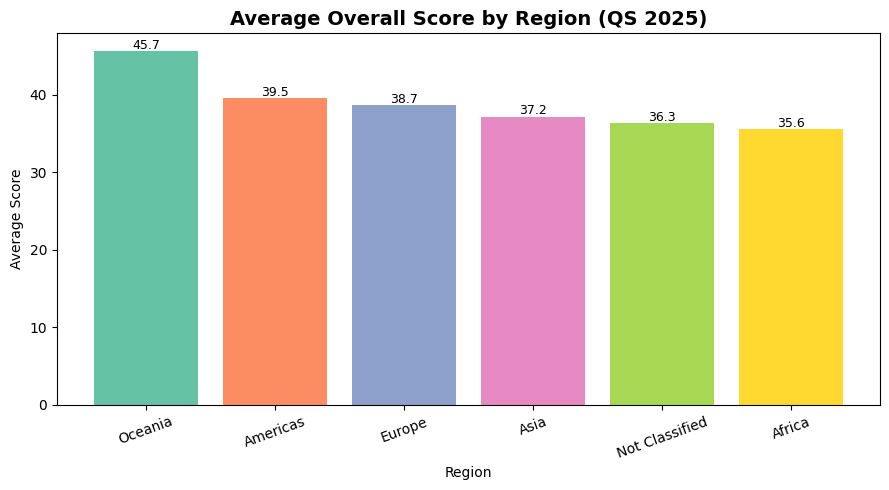

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(region_avg['Region'], region_avg['Avg_Score'],
              color=sns.color_palette('Set2', len(region_avg)))
ax.set_title('Average Overall Score by Region (QS 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Average Score')
for bar, val in zip(bars, region_avg['Avg_Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Interpretation:**

The Americas and Europe lead in average overall score, driven by elite US and UK universities. Asia is competitive but its average is pulled down by the large number of lower-ranked institutions. Africa and Oceania trail behind.


---
## Section 5: Analytical Use Cases

### Q9. Rank vs Score Relationship

In [67]:
scatter_df = df[['Institution_Name', 'RANK_2025', 'Overall_Score', 'Region']].dropna()
fig = px.scatter(
    scatter_df, x='RANK_2025', y='Overall_Score',
    color='Region', hover_name='Institution_Name',
    trendline='ols',
    title='Rank vs Overall Score (QS 2025)',
    labels={'RANK_2025': 'Rank 2025', 'Overall_Score': 'Overall Score'}
)
fig.show()


**Comment on Relationship:**

There is a strong negative relationship between rank and score â€” as rank number increases (lower position), the overall score drops sharply. The relationship is non-linear: scores fall steeply in the top 100 and then flatten out, meaning the difference between rank 500 and rank 1000 is much smaller than between rank 1 and rank 100.


### Q10. Top University per Country

In [68]:
def get_top_uni(group):
    """Return the row with the lowest (best) rank in each country group."""
    return group.loc[group['RANK_2025'].idxmin()]

top_per_country = (
    df.groupby('Location', group_keys=False)
      .apply(get_top_uni)
      .reset_index(drop=True)
      [['Location', 'Institution_Name', 'RANK_2025', 'Overall_Score']]
)
top_per_country.head(20)


KeyError: "['Location'] not in index"

### Q11. Outlier Detection

In [ ]:
col = 'Overall_Score'
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'IQR range: [{lower:.2f}, {upper:.2f}]')
print(f'Number of outliers: {len(outliers)}')
outliers[['Institution_Name', 'Overall_Score', 'RANK_2025']]


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df['Overall_Score'], color='lightcoral', ax=ax)
ax.set_title('Boxplot of Overall Score â€” Outlier Detection', fontsize=13, fontweight='bold')
ax.set_xlabel('Overall Score')
plt.tight_layout()
plt.show()


**Number of Outliers Found:**

The IQR method flags the top-scoring universities (roughly those scoring above ~85) as statistical outliers. This is expected â€” these are genuinely exceptional institutions that sit far above the bulk of the ranked list. They are not data errors; they represent the true elite tier.


### Q12. Score Category Analysis

In [ ]:
cat_counts = df['Score_Category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Count']
cat_counts


In [ ]:
order = ['Elite', 'High', 'Medium', 'Low']
cat_counts['Category'] = pd.Categorical(cat_counts['Category'], categories=order, ordered=True)
cat_counts = cat_counts.sort_values('Category')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax.bar(cat_counts['Category'], cat_counts['Count'], color=colors)
ax.set_title('Universities by Score Category (QS 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Score Category')
ax.set_ylabel('Number of Universities')
for bar, val in zip(bars, cat_counts['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()


**Interpretation:**

The vast majority of ranked universities fall in the **Low** category (score < 50), which reflects how competitive the global rankings are â€” most institutions that make the list are still far from the elite tier. The **Elite** category (score â‰¥ 90) contains only a tiny fraction, confirming that truly world-class universities are rare.


---
## Section 6: Advanced Analysis

### Q13. Country vs Average Rank

In [ ]:
country_rank = df.groupby('Location')['RANK_2025'].mean().reset_index()
country_rank.columns = ['Country', 'Avg_Rank']
country_rank = country_rank.sort_values('Avg_Rank').head(15)
country_rank


In [ ]:
best_country = country_rank.iloc[0]
print(f"Best performing country on average: {best_country['Country']} (avg rank {best_country['Avg_Rank']:.1f})")


In [ ]:
uni_count = df['Location'].value_counts().reset_index()
uni_count.columns = ['Country', 'Uni_Count']
merged = country_rank.merge(uni_count, on='Country')
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(merged['Uni_Count'], merged['Avg_Rank'],
                s=80, c=merged['Avg_Rank'], cmap='RdYlGn_r', edgecolors='k', linewidths=0.5)
for _, row in merged.iterrows():
    ax.annotate(row['Country'], (row['Uni_Count'], row['Avg_Rank']),
                fontsize=7, ha='left', va='bottom')
ax.set_xlabel('Number of Universities')
ax.set_ylabel('Average Rank (lower = better)')
ax.set_title('Country: Avg Rank vs Number of Universities', fontsize=13, fontweight='bold')
plt.colorbar(sc, label='Avg Rank')
plt.tight_layout()
plt.show()


### Q14. Multi-variable Visualization

In [ ]:
mv_df = df[['Institution_Name', 'Overall_Score', 'RANK_2025', 'Region']].dropna()
fig = px.scatter(
    mv_df, x='Overall_Score', y='RANK_2025',
    color='Region', size='Overall_Score',
    hover_name='Institution_Name',
    title='Score vs Rank by Region (QS 2025)',
    labels={'RANK_2025': 'Rank 2025', 'Overall_Score': 'Overall Score'},
    size_max=20
)
fig.update_yaxes(autorange='reversed')
fig.show()


**Insights:**

1. Americas and Europe dominate the top-left quadrant (high score, low rank number), confirming their global leadership.
2. Asian universities are spread across a wide score range, showing both elite institutions and a large number of mid-tier ones.
3. Bubble size (proportional to score) makes it visually clear that the top-ranked universities are significantly larger bubbles, reinforcing the score-rank relationship.


### Q15. Business Insight (Critical Thinking)

**If you are a policymaker:**

**What factors should universities improve?**
Universities should focus on improving **Citations per Faculty** and **Academic Reputation** â€” these two metrics have the highest correlation with overall score. Investing in research output, faculty quality, and international collaborations would yield the most ranking gains.

**Which regions lag behind?**
**Africa** and parts of **Latin America** consistently lag behind. Limited research funding, brain drain, and fewer international partnerships are key barriers. Policy interventions should target research grants and faculty exchange programs.

**What trends may shape future rankings?**
- The rise of **Asian universities** (China, South Korea, Singapore) is accelerating â€” heavy government investment is closing the gap with Western institutions.
- **Sustainability scores** are becoming a new differentiator; universities that embed sustainability into their operations will gain an edge.
- **Employer reputation** is growing in importance as the job market demands more applied skills.


---
## Section 7: Insights / Observations

### Summary of Key Insights

1. **Anglo-American Dominance:** The US and UK together account for the majority of top-50 universities, with MIT, Oxford, Cambridge, and Imperial consistently at the top.
2. **Score Distribution is Heavily Skewed:** Most ranked universities score below 50, while only a tiny elite tier scores above 90 â€” the ranking pyramid is extremely steep.
3. **Academic Reputation Drives Everything:** The strongest predictor of overall score is academic reputation, followed closely by employer reputation â€” prestige compounds itself.
4. **Asia is Rising Fast:** China, South Korea, and Singapore are rapidly increasing their representation in the top 100, driven by state investment in research and infrastructure.
5. **Sustainability is the New Frontier:** Universities with high sustainability scores (e.g., Imperial, NUS) are also climbing in overall rankings, suggesting this metric will matter more in future editions.
6. **Small Countries Punch Above Their Weight:** Singapore (NUS, NTU) and Switzerland (ETH Zurich, EPFL) have multiple top-50 universities despite small populations, showing that focused investment beats scale.


---
## Bonus Section (Optional)

### Q16. Ranking Prediction

In [ ]:
features = [
    'Academic_Reputation_Score', 'Employer_Reputation_Score',
    'Faculty_Student_Score', 'Citations_per_Faculty_Score',
    'International_Faculty_Score', 'International_Students_Score',
    'Employment_Outcomes_Score', 'Sustainability_Score'
]
target = 'Overall_Score'

model_df = df[features + [target]].dropna()
X = model_df[features].values
y = model_df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
preds = lr.predict(X_test)

rmse = mean_squared_error(y_test, preds, squared=False)
r2 = r2_score(y_test, preds)
print(f'RMSE: {rmse:.3f}')
print(f'R2 Score: {r2:.3f}')


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, preds, alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Score')
ax.set_ylabel('Predicted Score')
ax.set_title('Linear Regression: Actual vs Predicted Overall Score', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
coef_df


### Q17. Custom Insight

**Non-obvious Insight: Research-focused universities outperform comprehensive ones at the same rank band**

Universities with `FOCUS = FO` (focused/specialized) tend to have disproportionately high `Citations_per_Faculty_Score` compared to comprehensive (`FC`) universities at similar rank positions. This suggests that specialization drives research impact even when overall prestige is lower.


In [ ]:
focus_df = df[df['FOCUS'].isin(['FO', 'FC'])][['FOCUS', 'Citations_per_Faculty_Score', 'RANK_2025']].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=focus_df, x='FOCUS', y='Citations_per_Faculty_Score',
    palette={'FO': '#e74c3c', 'FC': '#3498db'}, ax=ax
)
ax.set_title('Citations per Faculty: Focused (FO) vs Comprehensive (FC) Universities',
             fontsize=12, fontweight='bold')
ax.set_xlabel('University Focus Type')
ax.set_ylabel('Citations per Faculty Score')
ax.set_xticklabels(['Focused (FO)', 'Comprehensive (FC)'])
plt.tight_layout()
plt.show()


**Explanation:**

Focused universities (FO) show a higher median citations-per-faculty score than comprehensive ones (FC). This makes intuitive sense â€” when a university concentrates on fewer disciplines, its faculty publish more within a narrower field, driving up citation counts. Policymakers looking to boost research impact quickly might consider encouraging specialization over breadth.
